# Assignment 2 - NLP

Andrea Sangio and Jana 4ever <3

In [1]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `nlp_assigment2` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `nlp

In [2]:
!pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [3]:
!pip install -U bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.4 MB/s eta 0:00:00


In [25]:
import pandas as pd
import os
from transformers import AutoTokenizer, DataCollatorWithPadding, pipeline
from transformers import AutoModelForCausalLM
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import BitsAndBytesConfig
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [5]:
FIGURE_SIZE = (5,5)
COLOR = 'salmon'

## 🧮Read and analyse data

In [6]:
data_file_path = os.path.join('data', 'a2_test.csv')
demonstrations_file_path = os.path.join('data', 'demonstrations.csv')
label = 'label_sexist'
text = 'text'
label_mapping = {"sexist": 1, "not sexist": 0}

In [54]:
def dataset_overview(df, label=label):
  display(df.head())

  print(f"\n\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

  print("\n\nMissing values:\n", df.isnull().sum())

  label_balance(df, label=label)

def text_length_analysis(df, label=label ,textl=text):
  df['text_length'] = df[text].apply(len)
  plt.figure(figsize=FIGURE_SIZE)
  df['text_length'].hist(bins=30,color=COLOR)
  plt.title('Text Length Distribution')
  plt.xlabel('Number of Characters')
  plt.ylabel('Frequency')
  plt.show()

  # Display basic statistics
  print(df['text_length'].describe())

  plt.figure(figsize=FIGURE_SIZE)
  sns.boxplot(data=df, x=label, y='text_length',color=COLOR)
  plt.title('Text Length by Class')
  plt.xlabel('Class')
  plt.ylabel('Text Length')
  plt.show()

def label_balance(df, label=label):
  # Visualize class distribution
  plt.figure(figsize=FIGURE_SIZE)
  sns.countplot(data=df, x=label, order=df[label].value_counts().index,color=COLOR)
  plt.title('Class Distribution')
  plt.xlabel('Class')
  plt.ylabel('Count')
  plt.show()

  # Display class proportions
  print("Class proportions:\n", df[label].value_counts(normalize=True))


def plot_predicted_classes_distribution(data):
  # Count occurrences of 1s and 0s
  counts = [data.count(0), data.count(1)]

  # Labels for the pie chart
  labels = ['Zero (0)', 'One (1)']

  # Create the pie chart
  plt.figure(figsize=FIGURE_SIZE)
  plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
  plt.title('Predicted classes by model distribution')
  plt.show()


def get_confusion_matrix(true_labels, predicted_labels):
  # Get the unique classes
  classes = [0,1]

  # Initialize the confusion matrix
  cm = np.zeros((len(classes), len(classes)), dtype=int)

  # Fill the confusion matrix
  for true, pred in zip(true_labels, predicted_labels):
      cm[classes.index(true)][classes.index(pred)] += 1

  # Visualize the confusion matrix
  plt.figure(figsize=FIGURE_SIZE)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.show()



,text,label_sexist
0,The boys must be gaming because there goes the...,0
1,Look at those eyes. Either someone unexpectedl...,1
2,Old man mogs everyone in this sub,0
3,"Excellent, I was just looking at another post ...",0
4,So you run back to daddy whenever you need hel...,1




Dataset contains 300 rows and 2 columns.


Missing values:
 text            0
label_sexist    0
dtype: int64


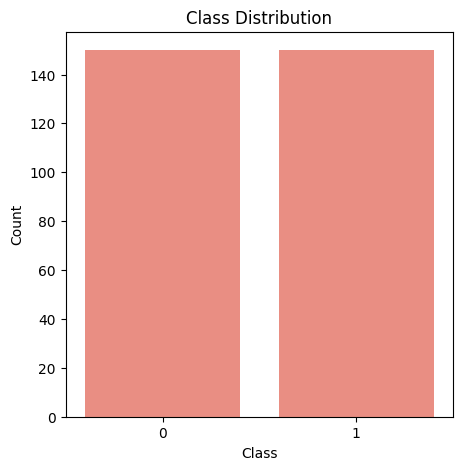

Class proportions:
 label_sexist
0    0.5
1    0.5
Name: proportion, dtype: float64


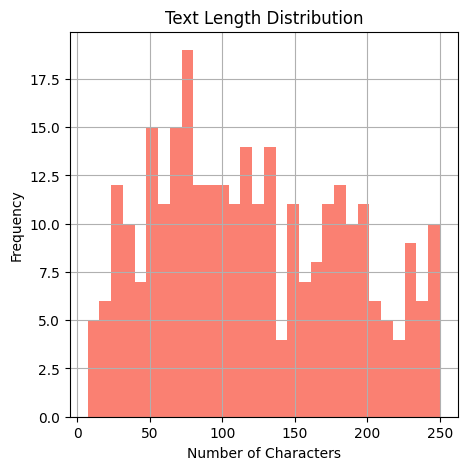

count    300.000000
mean     120.926667
std       64.839715
min        7.000000
25%       66.000000
50%      114.500000
75%      176.250000
max      250.000000
Name: text_length, dtype: float64


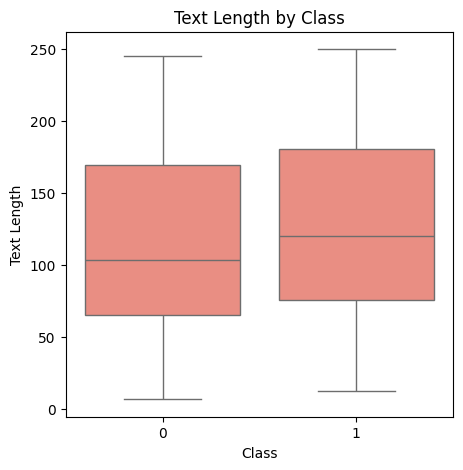

In [27]:
a2_test_data = pd.read_csv(data_file_path)
a2_test_data[label] = a2_test_data[label].map(label_mapping)
dataset_overview(a2_test_data[[text,label]])
text_length_analysis(a2_test_data[[text,label]])

,text,label_sexist
0,I would never have my kid go to a daycare with...,0
1,Democrat women are so butt fucking ugly.,1
2,If you really wanted to twist the knife you’d ...,0
3,Those women are pro-rape. They didn’t care abo...,1
4,Married a bitch... Is it the standard scenario...,1




Dataset contains 1000 rows and 2 columns.


Missing values:
 text            0
label_sexist    0
dtype: int64


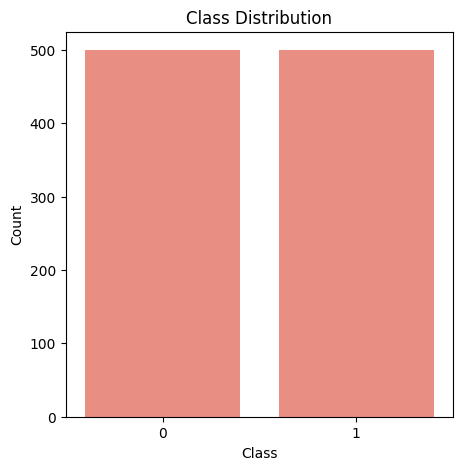

Class proportions:
 label_sexist
0    0.5
1    0.5
Name: proportion, dtype: float64


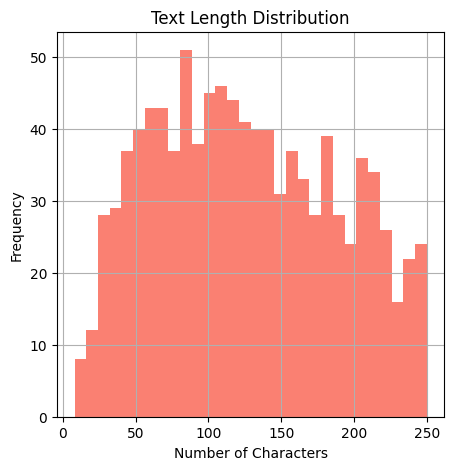

count    1000.000000
mean      126.036000
std        62.129081
min         8.000000
25%        74.000000
50%       120.000000
75%       177.000000
max       250.000000
Name: text_length, dtype: float64


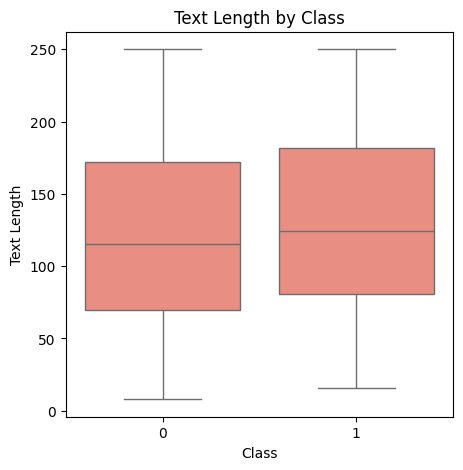

In [28]:
demonstrations = pd.read_csv(os.path.join('data', 'demonstrations.csv'))
demonstrations[label] = demonstrations[label].map(label_mapping)
dataset_overview(demonstrations[[text,label]])
text_length_analysis(demonstrations[[text,label]])

## ⚙️ Helper functions

In [10]:
prompt_zero_shot_template = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        TEXT:
        {text}

        ANSWER:
        """
    }
]

prompt_few_shot_template = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        {examples}

        TEXT:
        {text}

        ANSWER:
        """
    }
]

In [71]:
def prepare_prompts(texts, prompt_template, tokenizer, demonstrations=None, print_prompt_before_tokenization=False):
    """
    This function formats input text samples into instruction prompts.

    Inputs:
      texts: list of input texts to classify via prompting
      prompt_template: the prompt template provided in this assignment
      tokenizer: the transformers Tokenizer object instance associated with the chosen model card
      demonstrations: example text-sentiment pairs for the demonstrations

    Outputs:
      List of tokenized inputs, formatted into instruction prompts
    """
    formatted_prompts = []

    for text in texts:
        # Replace placeholder in prompt_template with actual text
        if demonstrations:
          prompt = prompt_template.format(text=text,examples=demonstrations)
        else:
          prompt = prompt_template.format(text=text)

        if print_prompt_before_tokenization:
          print(prompt)

        # Tokenize the formatted prompt using the provided tokenizer
        tokenized_prompt = tokenizer(prompt,return_tensors='pt').to(model.device)

        # Append the tokenized prompt to the list
        formatted_prompts.append(tokenized_prompt)

    return formatted_prompts


def generate_responses(model, prompt_examples, tokenizer, generation_config):
    """
    This function implements the inference loop for an LLM model.
    Given a set of examples, the model is tasked to generate a response.

    Inputs:
      model: LLM model instance for prompting
      prompt_examples: list of pre-processed text samples (tokenized prompts)
      tokenizer: Huggingface tokenizer instance
      generation_config: configuration for model generation

    Outputs:
      generated responses: list of model outputs
    """
    responses = []

    # Iterate over each prompt example and generate a response
    for example in prompt_examples:
        # Generate the response using the model
        generated = model.generate(input_ids=example['input_ids'].to(model.device),
                                   attention_mask=example['attention_mask'].to(model.device),
                                   generation_config=generation_config,
                                   do_sample=False)

        # Decode the output response
        output = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]

        # Store the response
        responses.append(output)

    return responses


def process_response(response):
    """
    This function takes a textual response generated by the LLM
    and processes it to map the response to a binary label.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed binary response: return 1 if YES and 0 if NO
    """
    # Assume that the model's response will either be "YES" or "NO" (you can adjust based on model output)

    if """ANSWER:
         YES""" in response or """[/INST] YES""" in response:
        return 1
    elif """ANSWER:
         NO""" in response or  """[/INST] NO""" in response:
        return 0
    else:
        return None  # If the response is neither YES nor NO, return None or handle appropriately


In [79]:
def compute_metrics(processed_responses, y_true):
    """
    This function takes predicted and ground-truth labels and computes metrics.
    In particular, it computes accuracy and fail-ratio metrics.
    This function internally invokes `process_response` to process the responses.

    Inputs:
      responses: list of generated LLM responses (strings)
      y_true: list or numpy array of ground-truth binary labels (0 or 1)

    Outputs:
      dictionary containing desired metrics: accuracy and fail-ratio
    """

    # Convert processed responses to numpy arrays for easy comparison
    processed_responses = np.array(processed_responses)
    y_true = np.array(y_true)

    # Calculate accuracy: Percentage of correct predictions
    correct_predictions = np.sum(processed_responses == y_true)
    total_predictions = len(processed_responses)
    accuracy = correct_predictions / total_predictions

    # Calculate fail-ratio: The ratio of failed responses (responses that do not answer in YES/NO)
    failed_responses = np.sum(processed_responses == 0)  # Consider 0 as failure for a "NO" answer
    fail_ratio = failed_responses / total_predictions

    return {
        "accuracy": accuracy,
        "fail-ratio": fail_ratio
    }

def inference_pipeline(texts, true_labels, prompt, tokenizer, model, generation_config, demonstrations = None, print_execution_time=True, print_metrics = True,  **kwargs):
    start_time = time.time()  # Record the start time
    # Prepare prompts
    prepared_prompts = prepare_prompts(texts, prompt, tokenizer, demonstrations, **kwargs)

    # Run inference
    generated_responses = generate_responses(model, prepared_prompts, tokenizer, generation_config)

    # Process the generated responses
    processed_responses = [process_response(response) for response in generated_responses]

    # Compute and output metrics
    metrics = compute_metrics(processed_responses, true_labels)
    if print_metrics:
      print(metrics)

    if print_execution_time:
      end_time = time.time()  # Record the end time
      execution_time = end_time - start_time  # Calculate the execution time
      print(f"Execution time: {execution_time:.6f} seconds")
    return processed_responses, metrics

In [47]:
def build_few_shot_demonstrations(demonstrations, label_column=label, text_column=text, num_per_class=2):
    """
    Inputs:
      demonstrations: the pandas.DataFrame object containing the demonstrations dataset.
      label_column: the column name in the DataFrame representing the labels (e.g., 'label_sexist').
      text_column: the column name in the DataFrame representing the text (e.g., 'text').
      num_per_class: number of demonstrations per class.

    Outputs:
      a string of formatted textual demonstrations to inject into the prompt template.
    """
    # Group the demonstrations by the label
    grouped = demonstrations.groupby(label_column)

    # Collect a few demonstrations per class
    few_shot_examples = []
    for label, group in grouped:
        # Select up to num_per_class examples per class
        examples = group.sample(n=min(num_per_class, len(group)), random_state=42)

        # Format the examples
        for _, row in examples.iterrows():
            sentiment = "YES" if row[label_column] == 1 else "NO"
            formatted_example = f"TEXT: {row[text_column]}\nANSWER: {sentiment}"
            few_shot_examples.append(formatted_example)

    # Combine the formatted examples into a single string
    demonstrations_str = '\n'.join(few_shot_examples)
    return demonstrations_str


### 🤖 Mistral v3

### 0️⃣ Zero-shot

In [14]:
model_card = "mistralai/Mistral-7B-Instruct-v0.3"
data = a2_test_data.copy()
display(data.head())

,rewire_id,text,label_sexist
0,sexism2022_english-17133,The boys must be gaming because there goes the...,0
1,sexism2022_english-14197,Look at those eyes. Either someone unexpectedl...,1
2,sexism2022_english-3018,Old man mogs everyone in this sub,0
3,sexism2022_english-5301,"Excellent, I was just looking at another post ...",0
4,sexism2022_english-17796,So you run back to daddy whenever you need hel...,1


In [15]:
tokenizer = AutoTokenizer.from_pretrained(model_card)
tokenizer.pad_token = tokenizer.eos_token
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

data = Dataset.from_pandas(data)
prompt_zero_shot = tokenizer.apply_chat_template(prompt_zero_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_zero_shot)  # Optional: To see the generated prompt

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]



=====PROMPT TEMPLATE=====
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        TEXT:
        {text}

        ANSWER:
        [/INST]


In [16]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enable 4-bit quantization
    bnb_4bit_use_double_quant=True,  # Optional: Enable double quantization for more efficiency
    bnb_4bit_quant_type="nf4",  # Use the "nf4" quantization type
    bnb_4bit_compute_dtype=torch.bfloat16,  # Optionally use bfloat16 for computation
)

model = AutoModelForCausalLM.from_pretrained(
    model_card,
    return_dict=True,
    quantization_config=bnb_config,
    device_map='auto'  # Automatically place the model on the available device (GPU or CPU)
)

generation_config = model.generation_config
generation_config.max_new_tokens = 100
generation_config.eos_token_id = tokenizer.eos_token_id
generation_config.pad_token_id = tokenizer.eos_token_id
generation_config.temperature = None
generation_config.num_return_sequences = 1

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [56]:
processed_responses, _  = inference_pipeline(list(data[text])[:20], list(data[label])[:20], prompt_zero_shot, tokenizer, model, generation_config)

{'accuracy': 0.55, 'fail-ratio': 0.1}
Execution time: 28.469309 seconds


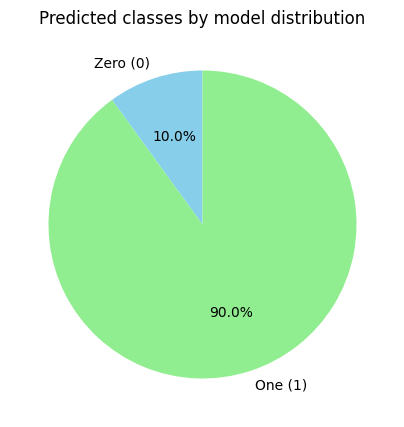

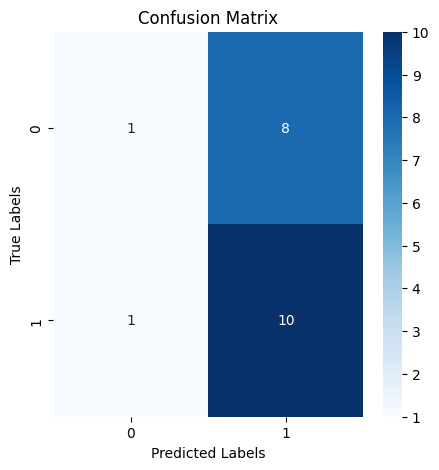

In [57]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label])[:20],processed_responses)

### Few-shot

Printed class balanced demonstration examples for few shot learning

In [51]:
print(build_few_shot_demonstrations(demonstrations))

TEXT: Can't see much of her but she's hotter than any vagina-hat wearer in the Women's March
ANSWER: NO
TEXT: DOES BLACK HAMILTON STAR DRUNK-RAPE WHITE WOMEN? If you name-check the VP-Elect of the United States in a one-sided insulting harangue, it'd be wise to delete the tweets that suggest you rape drunk white girls: #BoycottHamilton [URL]
ANSWER: NO
TEXT: nothing irks a left wing feminist worse than seeing a beautiful virtuous woman who is conservative they HATE her H-A-T-E so they try to suppress her next it will be illegal to be born beautiful they'll call it "Hate Birth"
ANSWER: YES
TEXT: Get #TRIGGERED, Hillaryfags, femme-fags, and feminazis: [URL] #MAGA #TRUMP #ELECTION2016 [URL]
ANSWER: YES


In [52]:
prompt_few_shot = tokenizer.apply_chat_template(prompt_few_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_few_shot)  # Optional: To see the generated prompt



=====PROMPT TEMPLATE=====
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        {examples}

        TEXT:
        {text}

        ANSWER:
        [/INST]


Example for number of examples per class = 2,3,4

In [53]:
random_index = random.randint(0, len(data[text]) - 1)
print(f'Random chosen example text: {data[text][random_index]}')
print(f'True label: {data[label][random_index]}')
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  response, _ = inference_pipeline([data[text][random_index]], [data[label][random_index]], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class),print_execution_time= False, print_metrics=False,print_prompt_before_tokenization=True)
  print(f"Response by model: {response[0]}")

Random chosen example text: Overheard at Star Wars RPG Night: “I cut open the door with my lightsaber and roll through the hole in one move. Best use of a Triumph EVER!” Me: “I don’t know. I once saw a guy pick up 3 hot girls in a TR-3.”
True label: 0
	== Number of examples per class for few-shot-learning = 2
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        TEXT: Can't see much of her but she's hotter than any vagina-hat wearer in the Women's March
ANSWER: NO
TEXT: DOES BLACK HAMILTON STAR DRUNK-RAPE WHITE WOMEN? If you name-check the VP-Elect of the United States in a one-sided insulting harangue, it'd be wise to delete the tweets that suggest you rape drunk white girls: #BoycottHamilton [URL]
ANSWER: NO
TEXT: nothing irks a left wing feminist worse than seeing a beautiful virtuous woman who is conservative they HATE her H-A-T-E so they try to suppress her next it w

	== Number of examples per class for few-shot-learning = 2
{'accuracy': 0.6, 'fail-ratio': 0.55}
Execution time: 56.115757 seconds


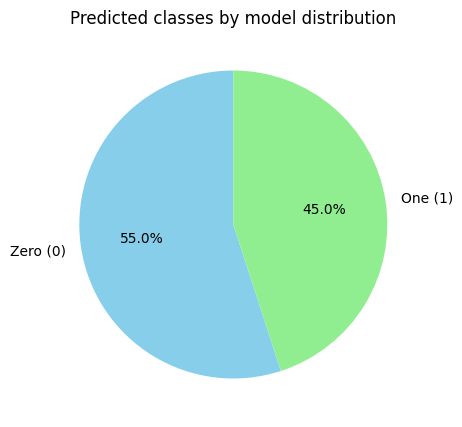

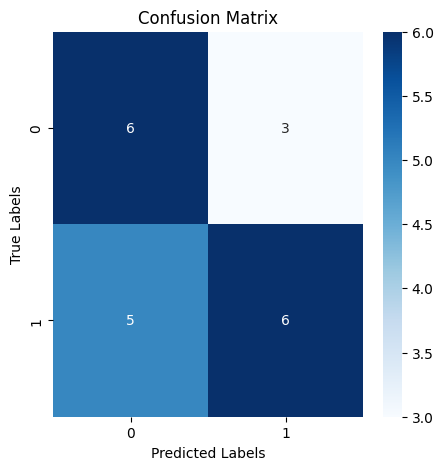

	== Number of examples per class for few-shot-learning = 3
{'accuracy': 0.7, 'fail-ratio': 0.65}
Execution time: 70.857311 seconds


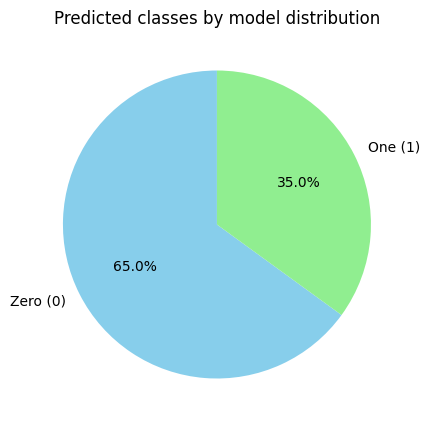

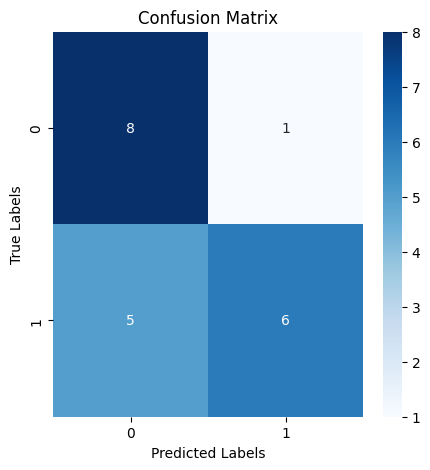

	== Number of examples per class for few-shot-learning = 4
{'accuracy': 0.65, 'fail-ratio': 0.6}
Execution time: 79.361387 seconds


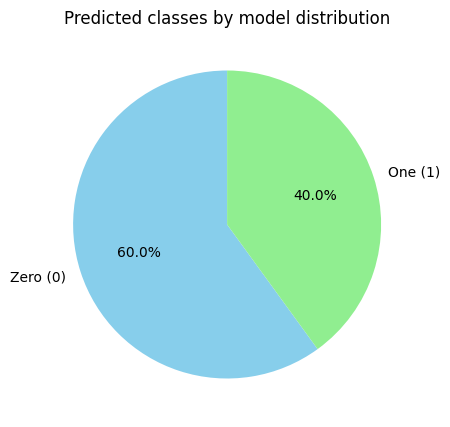

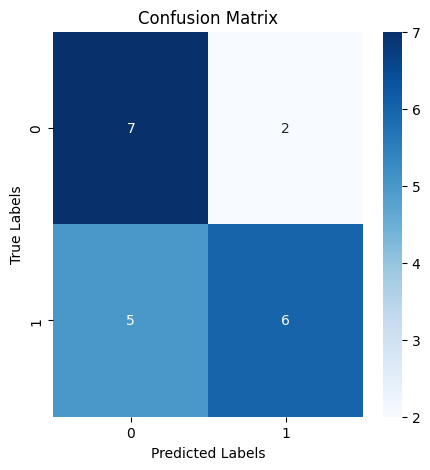

In [58]:
predicted_labels_list = []
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  processed_responses, _  = inference_pipeline(list(data[text])[:20], list(data[label])[:20], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class) )
  plot_predicted_classes_distribution(processed_responses)
  get_confusion_matrix(list(data[label])[:20],processed_responses)
  predicted_labels_list.append(processed_responses)

## Phi3-mini

### Zero-shot

In [59]:
model_card = "microsoft/Phi-3-mini-4k-instruct"
data = a2_test_data.copy()
display(data.head())

,rewire_id,text,label_sexist
0,sexism2022_english-17133,The boys must be gaming because there goes the...,0
1,sexism2022_english-14197,Look at those eyes. Either someone unexpectedl...,1
2,sexism2022_english-3018,Old man mogs everyone in this sub,0
3,sexism2022_english-5301,"Excellent, I was just looking at another post ...",0
4,sexism2022_english-17796,So you run back to daddy whenever you need hel...,1


In [60]:
tokenizer = AutoTokenizer.from_pretrained(model_card)
tokenizer.pad_token = tokenizer.eos_token
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]
data = Dataset.from_pandas(data)

prompt = tokenizer.apply_chat_template(prompt_zero_shot, tokenize=False, add_generation_prompt=True)

print("/n/n=====PROMPT TEMPLATE=====")
print(prompt)  # Optional: To see the generated prompt

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

/n/n=====PROMPT TEMPLATE=====
<|assistant|>



In [61]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enable 4-bit quantization
    bnb_4bit_use_double_quant=True,  # Optional: Enable double quantization for more efficiency
    bnb_4bit_quant_type="nf4",  # Use the "nf4" quantization type
    bnb_4bit_compute_dtype=torch.bfloat16,  # Optionally use bfloat16 for computation
)

model = AutoModelForCausalLM.from_pretrained(
    model_card,
    return_dict=True,
    quantization_config=bnb_config,
    device_map='auto'  # Automatically place the model on the available device (GPU or CPU)
)

generation_config = model.generation_config
generation_config.max_new_tokens = 100
generation_config.eos_token_id = tokenizer.eos_token_id
generation_config.pad_token_id = tokenizer.eos_token_id
generation_config.temperature = None
generation_config.num_return_sequences = 1

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [73]:
processed_responses, _  = inference_pipeline(list(data[text])[:20], list(data[label])[:20], prompt_zero_shot, tokenizer, model, generation_config)

{'accuracy': 0.65, 'fail-ratio': 0.6}
Execution time: 129.472308 seconds


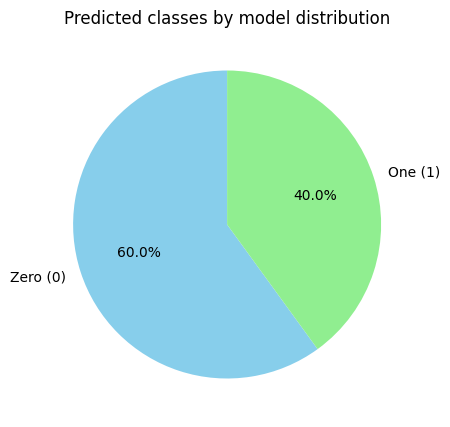

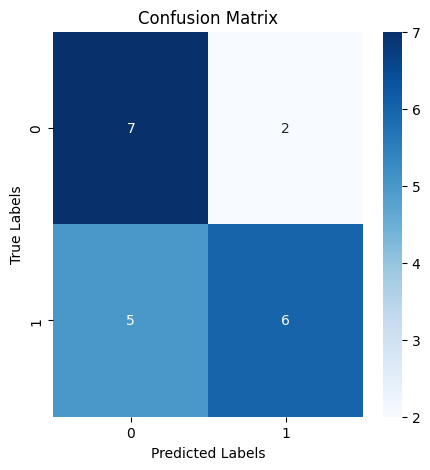

In [74]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label])[:20],processed_responses)

### Few-shot

In [76]:
random_index = random.randint(0, len(data[text]) - 1)
print(f'Random chosen example text: {data[text][random_index]}')
print(f'True label: {data[label][random_index]}')
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  response, _ = inference_pipeline([data[text][random_index]], [data[label][random_index]], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class), print_execution_time= False, print_metrics=False,print_prompt_before_tokenization=True)
  print(f"Response by model: {response[0]}")

Random chosen example text: [USER] · 8h8 hours ago Shouldn’t the most infamous loser in history shut her pie hole at this point? It’s becoming an authentic tragedy. #TumblingHag [URL]
True label: 1
	== Number of examples per class for few-shot-learning = 2
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        TEXT: Can't see much of her but she's hotter than any vagina-hat wearer in the Women's March
ANSWER: NO
TEXT: DOES BLACK HAMILTON STAR DRUNK-RAPE WHITE WOMEN? If you name-check the VP-Elect of the United States in a one-sided insulting harangue, it'd be wise to delete the tweets that suggest you rape drunk white girls: #BoycottHamilton [URL]
ANSWER: NO
TEXT: nothing irks a left wing feminist worse than seeing a beautiful virtuous woman who is conservative they HATE her H-A-T-E so they try to suppress her next it will be illegal to be born beautiful they'll call it "H

	== Number of examples per class for few-shot-learning = 2
{'accuracy': 0.5, 'fail-ratio': 0.95}
Execution time: 142.250666 seconds


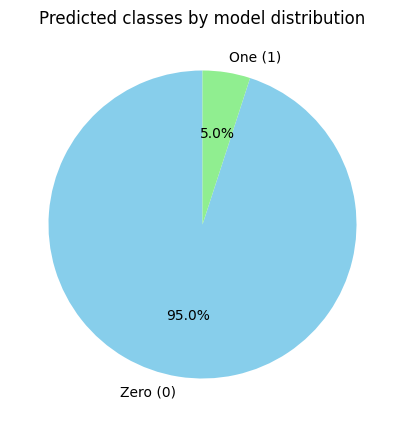

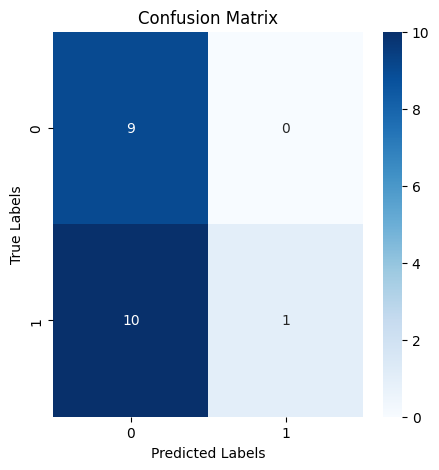

	== Number of examples per class for few-shot-learning = 3
{'accuracy': 0.5, 'fail-ratio': 0.95}
Execution time: 165.875926 seconds


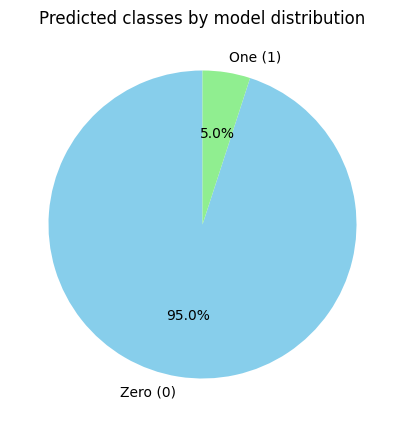

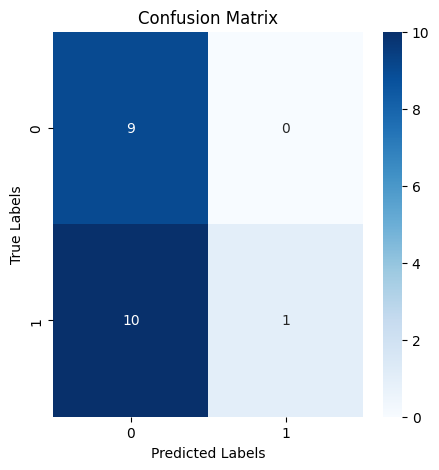

	== Number of examples per class for few-shot-learning = 4
{'accuracy': 0.5, 'fail-ratio': 0.95}
Execution time: 171.346962 seconds


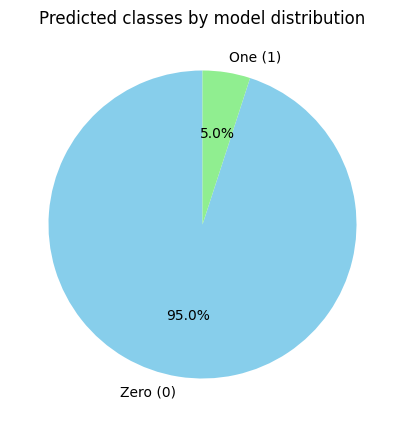

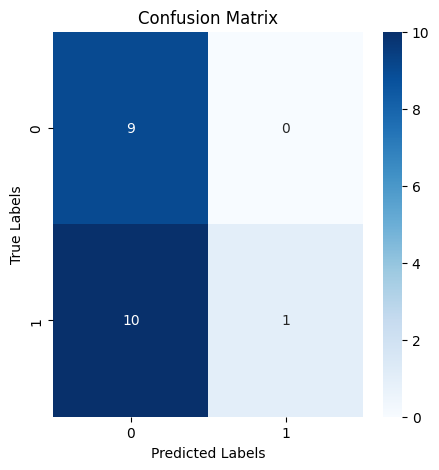

In [77]:
predicted_labels_list = []
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  processed_responses, _  = inference_pipeline(list(data[text])[:20], list(data[label])[:20], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class) )
  plot_predicted_classes_distribution(processed_responses)
  get_confusion_matrix(list(data[label])[:20],processed_responses)
  predicted_labels_list.append(processed_responses)

In [83]:
import pandas as pd

error_analysis = pd.DataFrame()
# Add predictions to the DataFrame
error_analysis['model1_preds'] = predicted_labels_list[0]
error_analysis['model2_preds'] = predicted_labels_list[1]
error_analysis['model3_preds'] = predicted_labels_list[2]
error_analysis['true_labels'] = list(data[label])[:20]

# Define helper columns to check correctness of each model
error_analysis['model1_correct'] = error_analysis['model1_preds'] == error_analysis['true_labels']
error_analysis['model2_correct'] = error_analysis['model2_preds'] == error_analysis['true_labels']
error_analysis['model3_correct'] = error_analysis['model3_preds'] == error_analysis['true_labels']

# Identify subsets
only_model1_correct = error_analysis[(error_analysis['model1_correct']) & (~error_analysis['model2_correct']) & (~error_analysis['model3_correct'])]
only_model2_correct = error_analysis[(~error_analysis['model1_correct']) & (error_analysis['model2_correct']) & (~error_analysis['model3_correct'])]
only_model3_correct = error_analysis[(~error_analysis['model1_correct']) & (~error_analysis['model2_correct']) & (error_analysis['model3_correct'])]
all_models_fail =error_analysis[(~error_analysis['model1_correct']) & (~error_analysis['model2_correct']) & (~error_analysis['model3_correct'])]

# Print results
print("Cases where only Model 1 is correct:")
print(only_model1_correct)

print("\nCases where only Model 2 is correct:")
print(only_model2_correct)

print("\nCases where only Model 3 is correct:")
print(only_model3_correct)

print("\nCases where all models fail:")
print(all_models_fail)

# Summary statistics
print("\nSummary:")
print(f"Only Model 1 Correct: {len(only_model1_correct)}")
print(f"Only Model 2 Correct: {len(only_model2_correct)}")
print(f"Only Model 3 Correct: {len(only_model3_correct)}")
print(f"All Models Fail: {len(all_models_fail)}")


Cases where only Model 1 is correct:
Empty DataFrame
Columns: [model1_preds, model2_preds, model3_preds, true_labels, model1_correct, model2_correct, model3_correct]
Index: []

Cases where only Model 2 is correct:
Empty DataFrame
Columns: [model1_preds, model2_preds, model3_preds, true_labels, model1_correct, model2_correct, model3_correct]
Index: []

Cases where only Model 3 is correct:
Empty DataFrame
Columns: [model1_preds, model2_preds, model3_preds, true_labels, model1_correct, model2_correct, model3_correct]
Index: []

Cases where all models fail:
    model1_preds  model2_preds  model3_preds  true_labels  model1_correct  \
1              0             0             0            1           False   
4              0             0             0            1           False   
5              0             0             0            1           False   
8              0             0             0            1           False   
9              0             0             0           